# Task 1 · Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a Linear Regression model that predicts house prices from features such as living area, location (city), number of rooms and age of the house, and go end-to-end: data cleaning → EDA → modelling → interpretation.

**Dataset:** `data.csv` – 4,600 house sales from King County / Seattle area, Washington (USA), May–July 2014.

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn.

**Notebook outline**
1. Load data & EDA (null check, descriptive statistics, target distribution)
2. Feature selection discussion
3. Data cleaning, feature engineering, one-hot encoding
4. Correlation heatmap
5. Train/test split (80/20)
6. Linear Regression model
7. Evaluation (MSE, RMSE, R²)
8. Actual vs predicted plot
9. Residual analysis
10. Coefficient analysis
11. Bonus – Ridge & Lasso comparison
12. Conclusions

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.options.display.float_format = lambda x: f"{x:,.4f}" if abs(x) < 10 else f"{x:,.0f}"
RANDOM_STATE = 42

## 1. Load Data & Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv("data.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,"313,000",3.0000,1.5000,1340,7912,1.5000,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,"2,384,000",5.0000,2.5000,3650,9050,2.0000,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,"342,000",3.0000,2.0000,1930,11947,1.0000,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,"420,000",3.0000,2.2500,2000,8030,1.0000,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,"550,000",4.0000,2.5000,1940,10500,1.0000,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


### 1.1 Null check, data types and duplicates

In [3]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulls": df.isnull().sum(),
    "null_%": (df.isnull().mean() * 100).round(2),
    "unique_values": df.nunique(),
})
print("Total missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows      :", int(df.duplicated().sum()))
info

Total missing values: 0
Duplicate rows      : 0


,dtype,nulls,null_%,unique_values
date,object,0,0.0000,70
price,float64,0,0.0000,1741
bedrooms,float64,0,0.0000,10
bathrooms,float64,0,0.0000,26
sqft_living,int64,0,0.0000,566
sqft_lot,int64,0,0.0000,3113
floors,float64,0,0.0000,6
waterfront,int64,0,0.0000,2
view,int64,0,0.0000,5
condition,int64,0,0.0000,5


### 1.2 Descriptive statistics

In [4]:
# Hidden data-quality problems that describe() hints at (min price = 0, weird yr_renovated, 0 bedrooms/bathrooms)
print("Rows with price == 0        :", (df["price"] == 0).sum())
print("Rows with bedrooms == 0     :", (df["bedrooms"] == 0).sum())
print("Rows with bathrooms == 0    :", (df["bathrooms"] == 0).sum())
print("Rows with yr_renovated == 0 :", (df["yr_renovated"] == 0).sum(), "(0 simply means 'never renovated')")
print("Highest 5 prices            :", df["price"].nlargest(5).astype(int).tolist())

Rows with price == 0        : 49
Rows with bedrooms == 0     : 2
Rows with bathrooms == 0    : 2
Rows with yr_renovated == 0 : 2735 (0 simply means 'never renovated')
Highest 5 prices            : [26590000, 12899000, 7062500, 4668000, 4489000]


### 1.3 Distribution of the target variable (price)

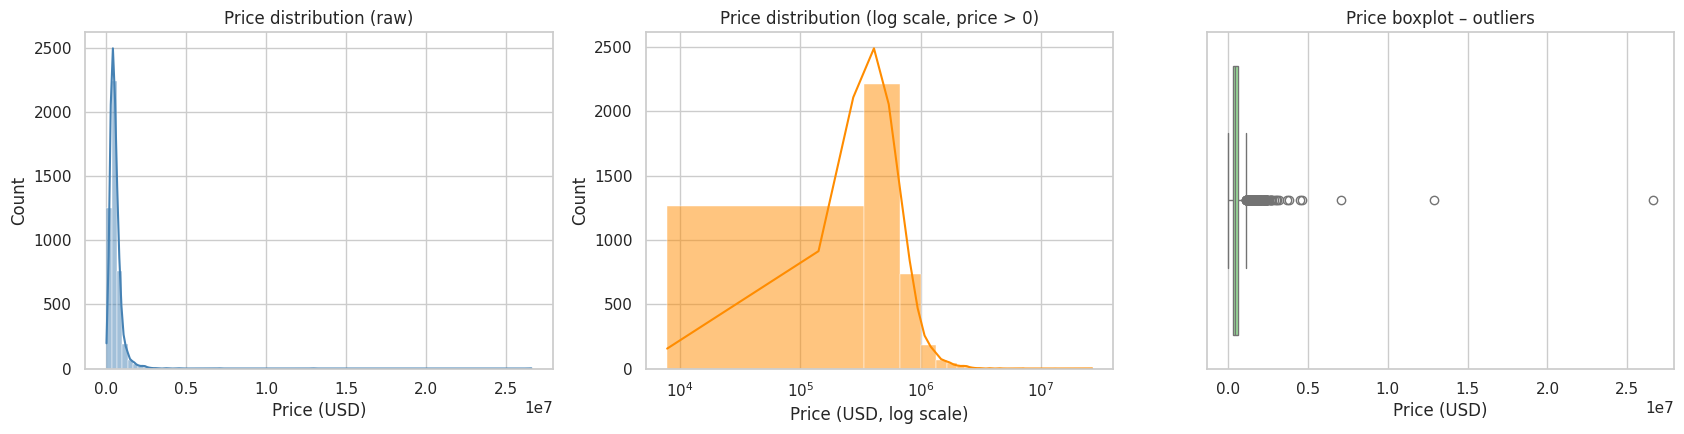

Mean price   :        551,963
Median price :        460,943
Skewness     :          24.79


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.histplot(df["price"], bins=80, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price (USD)")

sns.histplot(df.loc[df["price"] > 0, "price"], bins=80, kde=True, ax=axes[1], color="darkorange")
axes[1].set_xscale("log")
axes[1].set_title("Price distribution (log scale, price > 0)")
axes[1].set_xlabel("Price (USD, log scale)")

sns.boxplot(x=df["price"], ax=axes[2], color="lightgreen")
axes[2].set_title("Price boxplot – outliers")
axes[2].set_xlabel("Price (USD)")

plt.tight_layout()
plt.show()

print(f"Mean price   : {df['price'].mean():>14,.0f}")
print(f"Median price : {df['price'].median():>14,.0f}")
print(f"Skewness     : {df['price'].skew():>14.2f}")

**EDA observations**

* There are **no null values** and no duplicate rows, but that does *not* mean the data is clean.
* **49 houses have `price = 0`** – these are not real sale prices (missing/invalid values encoded as zero) and would badly distort a regression, so they will be removed.
* The price distribution is **strongly right-skewed**: the mean is well above the median, and a handful of extreme mansions (up to ~26.6 M USD) stretch the tail. Linear regression minimises squared errors, so a few extreme points can pull the fitted line strongly – I will treat the most extreme outliers explicitly.
* `yr_renovated = 0` means "never renovated" – it is a code, not a year, so it must be transformed before use.
* A few houses have 0 bedrooms / 0 bathrooms, which is implausible for a sold house.

## 3. Data Cleaning, Feature Engineering & Encoding

### 3.1 Handle invalid values / missing data

In [6]:
df_clean = df.copy()
n0 = len(df_clean)

# (a) price == 0 is an invalid value (treated as missing) -> remove
df_clean = df_clean[df_clean["price"] > 0]
print(f"Removed {n0 - len(df_clean)} rows with price = 0")

# (b) 0 bedrooms / 0 bathrooms are implausible for a sold house -> remove
n1 = len(df_clean)
df_clean = df_clean[(df_clean["bedrooms"] > 0) & (df_clean["bathrooms"] > 0)]
print(f"Removed {n1 - len(df_clean)} rows with 0 bedrooms or 0 bathrooms")

# (c) Extreme price outliers (> Q3 + 3*IQR) -> remove; they dominate squared-error loss
q1, q3 = df_clean["price"].quantile([0.25, 0.75])
upper = q3 + 3 * (q3 - q1)
n2 = len(df_clean)
df_clean = df_clean[df_clean["price"] <= upper]
print(f"Removed {n2 - len(df_clean)} extreme outliers with price > {upper:,.0f}")

print(f"\nRows: {n0} -> {len(df_clean)}  ({n0 - len(df_clean)} removed, {(n0 - len(df_clean)) / n0:.1%})")
print("Missing values left:", int(df_clean.isnull().sum().sum()))

Removed 49 rows with price = 0
Removed 2 rows with 0 bedrooms or 0 bathrooms
Removed 89 extreme outliers with price > 1,651,700

Rows: 4600 -> 4460  (140 removed, 3.0%)
Missing values left: 0


### 3.2 Feature engineering

In [7]:
SALE_YEAR = 2014   # the data covers sales made in 2014
df_clean["house_age"] = SALE_YEAR - df_clean["yr_built"]
df_clean["is_renovated"] = (df_clean["yr_renovated"] > 0).astype(int)

# Drop columns discussed in Section 2
drop_cols = ["date", "street", "statezip", "country", "sqft_above", "yr_built", "yr_renovated"]
df_model = df_clean.drop(columns=drop_cols).reset_index(drop=True)

print("Columns kept:", df_model.columns.tolist())
df_model.head()

Columns kept: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_basement', 'city', 'house_age', 'is_renovated']


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_basement,city,house_age,is_renovated
0,"313,000",3.0000,1.5000,1340,7912,1.5000,0,0,3,0,Shoreline,59,1
1,"342,000",3.0000,2.0000,1930,11947,1.0000,0,0,4,0,Kent,48,0
2,"420,000",3.0000,2.2500,2000,8030,1.0000,0,0,4,1000,Bellevue,51,0
3,"550,000",4.0000,2.5000,1940,10500,1.0000,0,0,4,800,Redmond,38,1
4,"490,000",2.0000,1.0000,880,6380,1.0000,0,0,3,0,Seattle,76,1


### 3.3 Distribution after cleaning

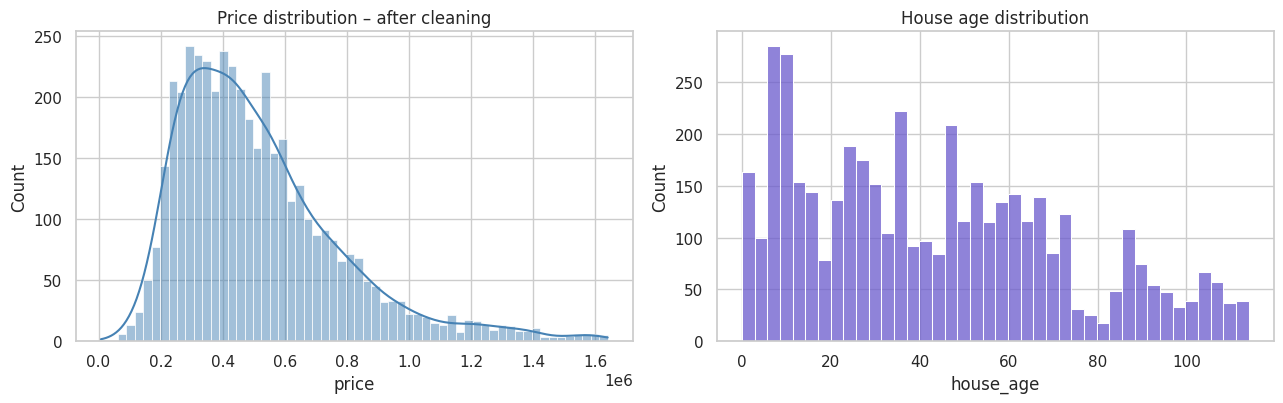

Price skewness before: 24.79  ->  after: 1.30


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(df_model["price"], bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Price distribution – after cleaning")
sns.histplot(df_model["house_age"], bins=40, ax=axes[1], color="slateblue")
axes[1].set_title("House age distribution")
plt.tight_layout(); plt.show()
print(f"Price skewness before: {df['price'].skew():.2f}  ->  after: {df_model['price'].skew():.2f}")

### 3.4 One-Hot Encoding of categorical feature (`city`)

In [9]:
print("Number of cities:", df_model["city"].nunique())

# drop_first=True avoids the dummy-variable trap (perfect multicollinearity)
df_encoded = pd.get_dummies(df_model, columns=["city"], drop_first=True, dtype=int)
baseline_city = sorted(df_model["city"].unique())[0]
print("Baseline (dropped) city:", baseline_city)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Number of cities: 44
Baseline (dropped) city: Algona
Shape after encoding: (4460, 55)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_basement,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
0,"313,000",3.0000,1.5000,1340,7912,1.5000,0,0,3,0,...,0,0,1,0,0,0,0,0,0,0
1,"342,000",3.0000,2.0000,1930,11947,1.0000,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2,"420,000",3.0000,2.2500,2000,8030,1.0000,0,0,4,1000,...,0,0,0,0,0,0,0,0,0,0
3,"550,000",4.0000,2.5000,1940,10500,1.0000,0,0,4,800,...,0,0,0,0,0,0,0,0,0,0
4,"490,000",2.0000,1.0000,880,6380,1.0000,0,0,3,0,...,0,1,0,0,0,0,0,0,0,0


## 4. Correlation Heatmap

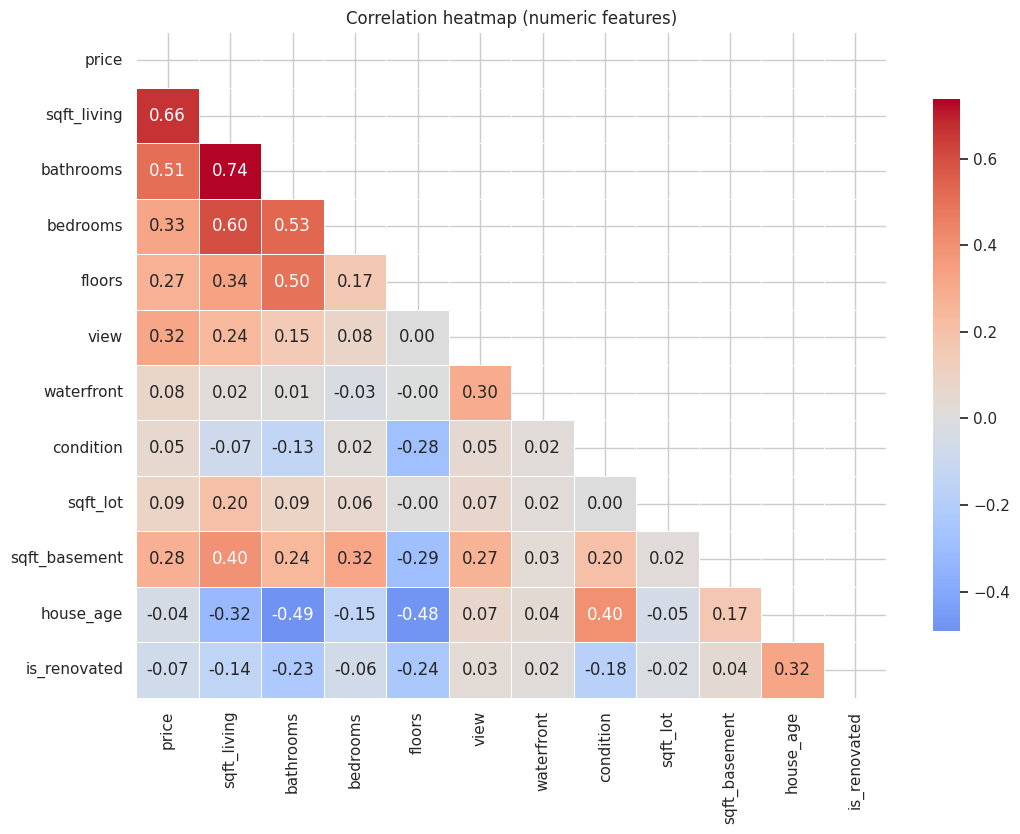

In [10]:
num_cols = ["price", "sqft_living", "bathrooms", "bedrooms", "floors", "view", "waterfront",
            "condition", "sqft_lot", "sqft_basement", "house_age", "is_renovated"]
corr = df_model[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(11, 8.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout(); plt.show()

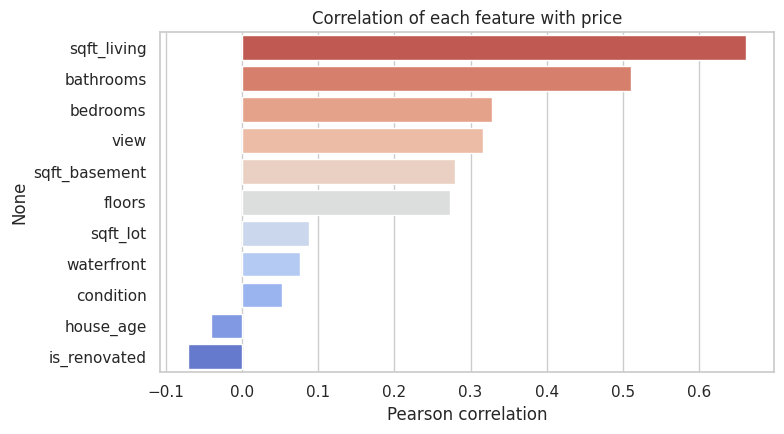

,correlation_with_price
sqft_living,0.6622
bathrooms,0.5106
bedrooms,0.3282
view,0.3164
sqft_basement,0.2799
floors,0.2736
sqft_lot,0.0883
waterfront,0.0754
condition,0.0528
house_age,-0.0409


In [11]:
price_corr = corr["price"].drop("price").sort_values(ascending=False)

plt.figure(figsize=(8, 4.5))
sns.barplot(x=price_corr.values, y=price_corr.index, palette="coolwarm_r")
plt.title("Correlation of each feature with price")
plt.xlabel("Pearson correlation")
plt.tight_layout(); plt.show()

price_corr.to_frame("correlation_with_price")

**Interpretation:** `sqft_living` is by far the strongest correlate of price, followed by `bathrooms` (≈0.5), then `bedrooms`, `view`, `sqft_basement` and `floors` (≈0.3 each). `sqft_lot`, `waterfront`, `condition`, `house_age` and `is_renovated` show only a weak *linear* relationship on their own (note: waterfront is very rare – under 1% of houses – so its correlation is small even though waterfront homes are pricey). `bedrooms`/`bathrooms` are also correlated with `sqft_living` (bigger houses have more rooms), which will matter for the coefficients. Correlation only captures *linear, one-at-a-time* relationships; **location (city)** cannot appear in this heatmap but will matter a lot in the model, as the coefficient analysis will show.

## 5. Train / Test Split (80 / 20)

In [12]:
X = df_encoded.drop(columns="price")
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Features        : {X.shape[1]}")
print(f"Training set    : {X_train.shape[0]} rows ({X_train.shape[0] / len(X):.0%})")
print(f"Test set        : {X_test.shape[0]} rows ({X_test.shape[0] / len(X):.0%})")

Features        : 54
Training set    : 3568 rows (80%)
Test set        : 892 rows (20%)


## 6. Train a Linear Regression Model

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)
print("Model trained. Intercept:", f"{lr.intercept_:,.0f}")

Model trained. Intercept: -272,144


## 7. Model Evaluation – MSE, RMSE, R²

In [14]:
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"MSE": mse, "RMSE": np.sqrt(mse),
            "MAE": mean_absolute_error(y_true, y_pred), "R²": r2_score(y_true, y_pred)}

results_lr = pd.DataFrame({"Train": evaluate(y_train, y_train_pred),
                           "Test": evaluate(y_test, y_test_pred)}).T
print(f"Mean house price in the test set: {y_test.mean():,.0f} USD\n")
results_lr

Mean house price in the test set: 518,892 USD



,MSE,RMSE,MAE,R²
Train,"20,325,537,370","142,568","97,050",0.7054
Test,"20,837,955,526","144,354","99,663",0.7046


**How to read this**

* **MSE** is in squared dollars, so it is hard to interpret directly. **RMSE** brings it back to dollars: it is the typical size of a prediction error (large errors are penalised more).
* **R²** is the share of price variance the model explains (1.0 = perfect, 0 = no better than always predicting the mean).
* Train and test scores are close to each other, so the model is **not overfitting** – it generalises to unseen houses.

## 8. Scatter Plot – Actual vs Predicted Prices

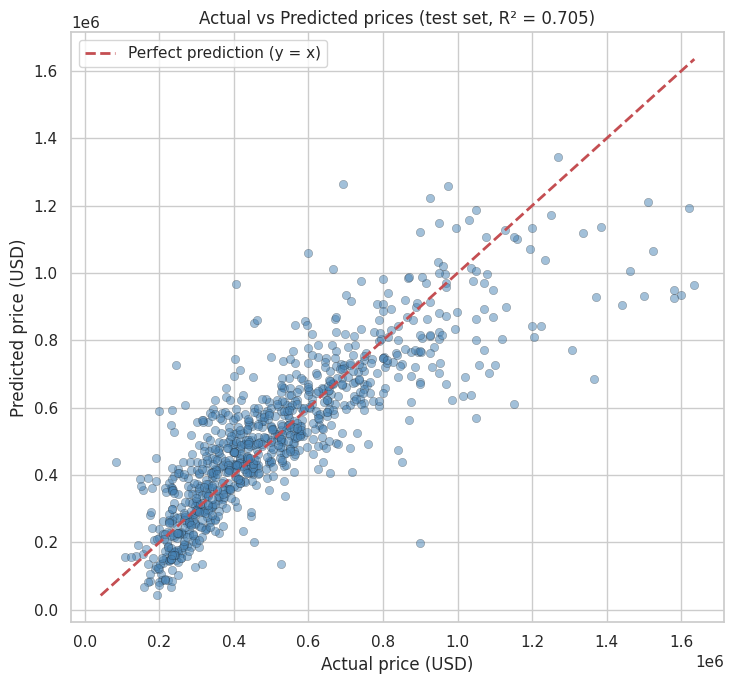

In [15]:
plt.figure(figsize=(7.5, 7))
plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolor="k", linewidth=0.3, color="steelblue")
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, "r--", lw=2, label="Perfect prediction (y = x)")
plt.xlabel("Actual price (USD)")
plt.ylabel("Predicted price (USD)")
plt.title(f"Actual vs Predicted prices (test set, R² = {r2_score(y_test, y_test_pred):.3f})")
plt.legend()
plt.tight_layout(); plt.show()

## 9. Residual Analysis

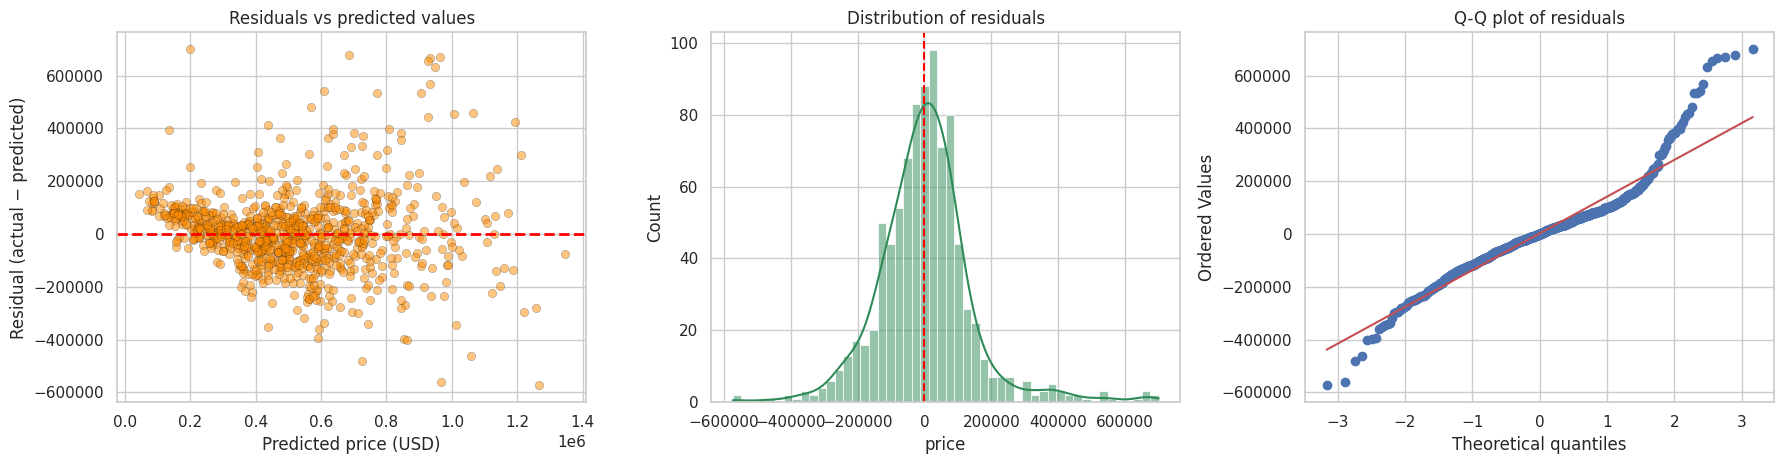

Mean of residuals: 2,506  (should be close to 0)
Std of residuals : 144,413
Skewness of residuals: 0.81


In [16]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].scatter(y_test_pred, residuals, alpha=0.5, edgecolor="k", linewidth=0.3, color="darkorange")
axes[0].axhline(0, color="red", ls="--", lw=2)
axes[0].set_xlabel("Predicted price (USD)"); axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs predicted values")

sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color="seagreen")
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title("Distribution of residuals")

from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of residuals")

plt.tight_layout(); plt.show()
print(f"Mean of residuals: {residuals.mean():,.0f}  (should be close to 0)")
print(f"Std of residuals : {residuals.std():,.0f}")
print(f"Skewness of residuals: {residuals.skew():.2f}")

## 10. Coefficient Analysis

In [17]:
coef = pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False)
coef_df = coef.to_frame("coefficient")
coef_df["type"] = np.where(coef_df.index.str.startswith("city_"), "city (vs " + baseline_city + ")", "property feature")

print("Top 10 POSITIVE impact on price:")
display(coef_df.head(10))
neg = coef_df[coef_df["coefficient"] < 0].sort_values("coefficient")
print(f"NEGATIVE impact on price (only {len(neg)} of {len(coef_df)} features have a negative coefficient):")
display(neg)

Top 10 POSITIVE impact on price:


,coefficient,type
city_Clyde Hill,"780,222",city (vs Algona)
city_Beaux Arts Village,"551,353",city (vs Algona)
city_Mercer Island,"484,227",city (vs Algona)
city_Medina,"468,792",city (vs Algona)
city_Bellevue,"374,492",city (vs Algona)
city_Kirkland,"307,928",city (vs Algona)
city_Redmond,"304,986",city (vs Algona)
city_Seattle,"291,623",city (vs Algona)
city_Sammamish,"251,374",city (vs Algona)
city_Snoqualmie Pass,"242,676",city (vs Algona)


NEGATIVE impact on price (only 3 of 54 features have a negative coefficient):


,coefficient,type
bedrooms,"-24,071",property feature
sqft_basement,-70,property feature
sqft_lot,-0.0371,property feature


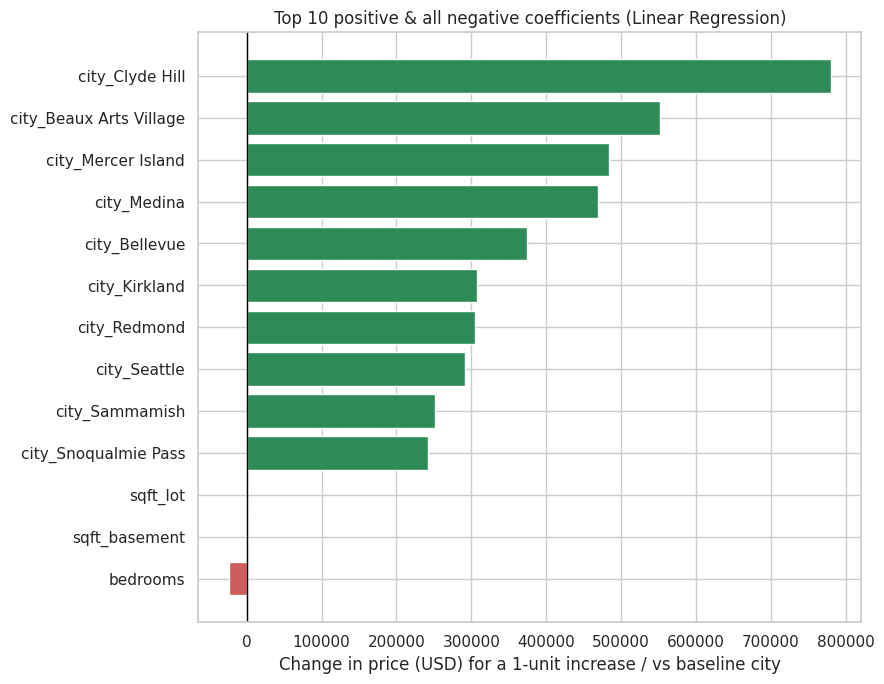

In [18]:
top = pd.concat([coef.head(10), coef[coef < 0].sort_values(ascending=False)])
colors = ["seagreen" if v > 0 else "indianred" for v in top.values]

plt.figure(figsize=(9, 7))
plt.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", lw=1)
plt.title("Top 10 positive & all negative coefficients (Linear Regression)")
plt.xlabel("Change in price (USD) for a 1-unit increase / vs baseline city")
plt.tight_layout(); plt.show()

**Note on comparing numeric features:** raw coefficients depend on the unit of each feature (e.g. +1 `sqft_living` vs +1 `waterfront` flag), so they can't be ranked fairly. Below I standardise the numeric features (mean 0, std 1) so each coefficient means *"price change for a 1-standard-deviation increase"*.

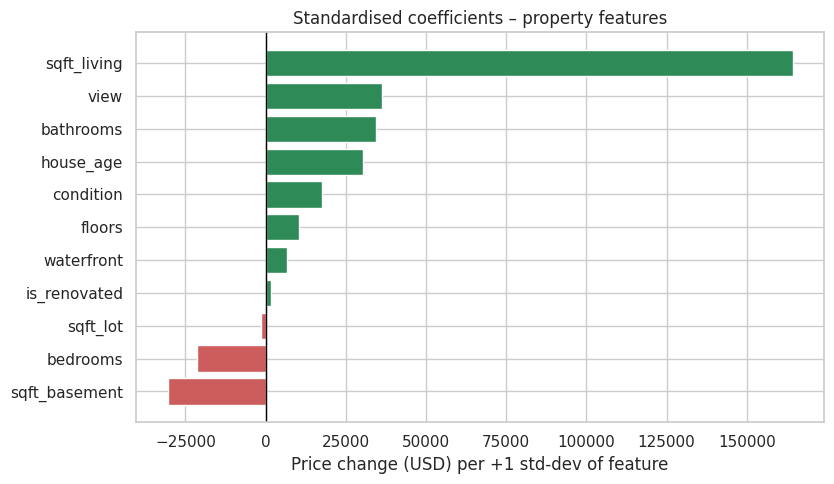

,std_coefficient
sqft_living,"164,355"
view,"36,183"
bathrooms,"34,478"
house_age,"30,304"
condition,"17,466"
floors,"10,423"
waterfront,"6,603"
is_renovated,"1,643"
sqft_lot,"-1,346"
bedrooms,"-21,448"


In [19]:
prop_features = [c for c in X.columns if not c.startswith("city_")]
scaled_lr = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
std_coef = pd.Series(scaled_lr[-1].coef_, index=X.columns)[prop_features].sort_values()

plt.figure(figsize=(8.5, 5))
plt.barh(std_coef.index, std_coef.values, color=["indianred" if v < 0 else "seagreen" for v in std_coef.values])
plt.axvline(0, color="black", lw=1)
plt.title("Standardised coefficients – property features")
plt.xlabel("Price change (USD) per +1 std-dev of feature")
plt.tight_layout(); plt.show()

std_coef.sort_values(ascending=False).to_frame("std_coefficient")


**Coefficient interpretation** (all other features held constant)

*Largest positive impact*
* **Location dominates.** City coefficients are measured *relative to the baseline city (Algona, one of the cheapest)*. Affluent Eastside/lake areas – **Clyde Hill (+~780k), Beaux Arts Village (+~550k), Mercer Island (+~485k), Medina (+~470k), Bellevue (+~375k)** – carry the biggest premiums, followed by Kirkland, Redmond, Seattle and Sammamish (+250–310k).
* **`sqft_living`**: about **+192 USD per extra square foot**, and it is by far the strongest *property* feature once features are put on a common scale (standardised chart), ahead of `view`, `bathrooms`, `house_age`, `condition` and `floors`.

*Negative / surprising signs* (worth explaining, not blindly trusting)
* **`bedrooms` ≈ −24k per extra bedroom.** This does not mean bedrooms reduce value: `sqft_living` is already in the model, so an extra bedroom at the *same total area* means smaller rooms – a classic multicollinearity effect.
* **`sqft_basement` ≈ −70 USD/sqft.** Basement area is also part of `sqft_living`, so its net value is roughly 192 − 70 ≈ 120 USD/sqft: basement space is worth less than above-ground space.
* **`sqft_lot` ≈ 0** (−0.04 USD per sq ft): lot size adds almost nothing once city and house size are known.
* **`house_age` is *positive* (≈ +1,000 USD per year of age).** Holding city and size fixed, older homes sell for slightly more – plausibly because older homes sit in established, central neighbourhoods. This is an association, not a causal claim.

*Caveat:* every city coefficient is positive (or zero) simply because the baseline city, Algona, is cheap; the ranking *between* cities is what matters. Coefficients are also sensitive to correlated features, which is one motivation for the regularised models below.


## 11. (Bonus) Linear Regression vs Ridge vs Lasso
Regularised models add a penalty on coefficient size (Ridge: L2, Lasso: L1 – which can shrink coefficients to exactly zero, acting as feature selection). Features are **standardised** first (required for a fair penalty) and the regularisation strength `alpha` is chosen by 5-fold cross-validation on the training set only.

In [20]:
alphas = np.logspace(-2, 4, 50)

ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5)).fit(X_train, y_train)
lasso = make_pipeline(StandardScaler(), LassoCV(alphas=None, cv=5, random_state=RANDOM_STATE, max_iter=50000)).fit(X_train, y_train)

print(f"Best Ridge alpha: {ridge[-1].alpha_:.2f}")
print(f"Best Lasso alpha: {lasso[-1].alpha_:.2f}")

models = {"Linear Regression": lr, "Ridge": ridge, "Lasso": lasso}
rows = []
for name, m in models.items():
    for split, (Xs, ys) in {"Train": (X_train, y_train), "Test": (X_test, y_test)}.items():
        r = evaluate(ys, m.predict(Xs)); r.update(Model=name, Split=split); rows.append(r)
comparison = pd.DataFrame(rows).set_index(["Model", "Split"])
comparison

Best Ridge alpha: 26.83
Best Lasso alpha: 185.40


MSE    RMSE    MAE     R²
Model             Split                                     
Linear Regression Train 20,325,537,370 142,568 97,050 0.7054
                  Test  20,837,955,526 144,354 99,663 0.7046
Ridge             Train 20,366,233,151 142,710 97,115 0.7048
                  Test  20,761,599,425 144,089 99,500 0.7057
Lasso             Train 20,345,731,768 142,638 97,112 0.7051
                  Test  20,746,221,871 144,035 99,487 0.7059

Lasso set 4 of 54 coefficients exactly to zero (automatic feature selection).


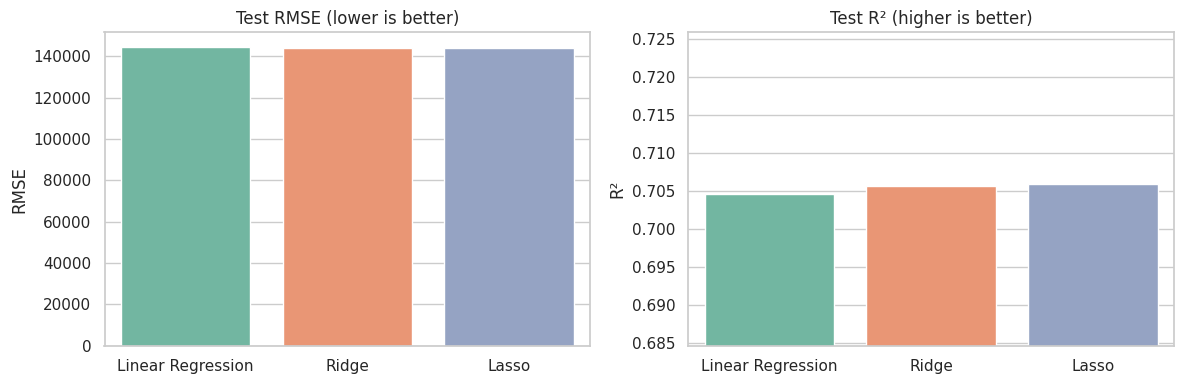

In [21]:
n_zero = int((np.abs(lasso[-1].coef_) < 1e-8).sum())
print(f"Lasso set {n_zero} of {X.shape[1]} coefficients exactly to zero (automatic feature selection).")

test_cmp = comparison.xs("Test", level="Split")[["RMSE", "R²"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=test_cmp.index, y=test_cmp["RMSE"], ax=axes[0], palette="Set2")
axes[0].set_title("Test RMSE (lower is better)"); axes[0].set_xlabel("")
sns.barplot(x=test_cmp.index, y=test_cmp["R²"], ax=axes[1], palette="Set2")
axes[1].set_title("Test R² (higher is better)"); axes[1].set_xlabel("")
axes[1].set_ylim(test_cmp["R²"].min() - 0.02, test_cmp["R²"].max() + 0.02)
plt.tight_layout(); plt.show()

In [22]:
# How do coefficients shrink? (all models on the same standardised scale)
coef_cmp = pd.DataFrame({
    "Linear": scaled_lr[-1].coef_,
    "Ridge": ridge[-1].coef_,
    "Lasso": lasso[-1].coef_,
}, index=X.columns)
coef_cmp.reindex(coef_cmp["Linear"].abs().sort_values(ascending=False).index).head(12)

,Linear,Ridge,Lasso
sqft_living,"164,355","160,523","164,131"
city_Seattle,"138,997","53,888","77,999"
city_Bellevue,"88,335","46,473","57,971"
city_Redmond,"68,139","28,818","39,409"
city_Kirkland,"59,376","25,219","34,545"
city_Mercer Island,"59,118","37,434","43,366"
city_Sammamish,"47,791","14,573","23,337"
city_Issaquah,"47,494","12,168","21,787"
view,"36,183","36,282","35,982"
city_Woodinville,"34,693","7,380","14,569"


### Extra: modelling `log(price)`
Since the residual plot showed heteroscedasticity, one more quick experiment: fit the same linear model on `log(price)` and convert predictions back to dollars.

Log-price model, evaluated on the ORIGINAL price scale (test set):
{'MSE': 23903873805, 'RMSE': 154609, 'MAE': 99249, 'R²': 0.661}
R² on log-price scale: 0.727


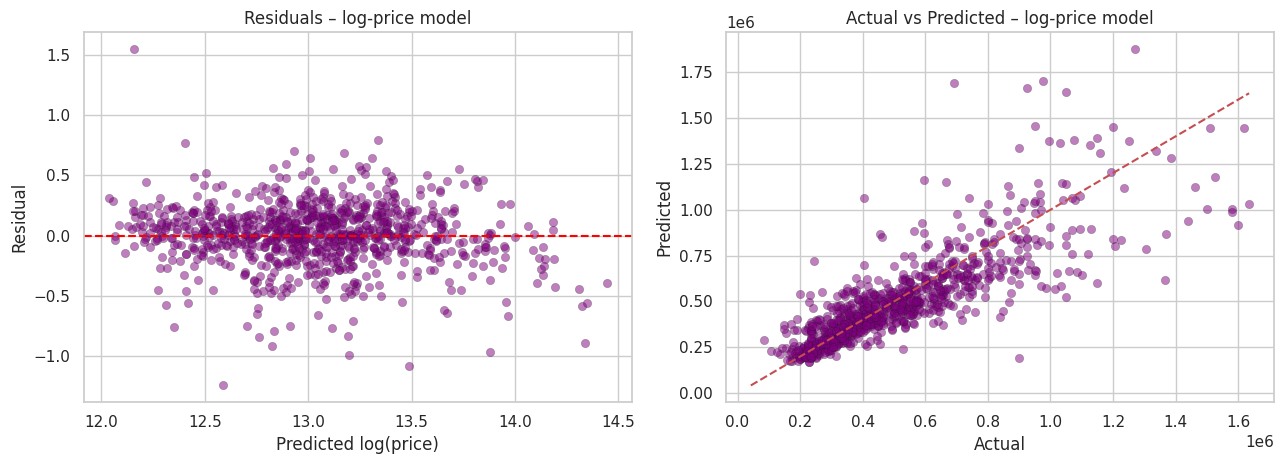

In [23]:
lr_log = LinearRegression().fit(X_train, np.log(y_train))
pred_log_back = np.exp(lr_log.predict(X_test))

res_log = evaluate(y_test, pred_log_back)
print("Log-price model, evaluated on the ORIGINAL price scale (test set):")
print({k: round(v, 3) if k == "R²" else round(v) for k, v in res_log.items()})
print(f"R² on log-price scale: {r2_score(np.log(y_test), lr_log.predict(X_test)):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(lr_log.predict(X_test), np.log(y_test) - lr_log.predict(X_test), alpha=0.5, color="purple", edgecolor="k", linewidth=0.3)
axes[0].axhline(0, color="red", ls="--"); axes[0].set_title("Residuals – log-price model")
axes[0].set_xlabel("Predicted log(price)"); axes[0].set_ylabel("Residual")
axes[1].scatter(y_test, pred_log_back, alpha=0.5, color="purple", edgecolor="k", linewidth=0.3)
axes[1].plot(lims, lims, "r--"); axes[1].set_title("Actual vs Predicted – log-price model")
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")
plt.tight_layout(); plt.show()


## 12. Conclusions

* **Performance:** on the unseen 20% test set the model reaches **R² ≈ 0.70 (0.705)** with an **RMSE ≈ 144k USD** and **MAE ≈ 100k USD** (average house in the test set ≈ 519k USD). Train and test scores are almost identical, so there is no overfitting; roughly **62% of predictions fall within ±20%** of the true price.
* **Main drivers:** location (city) and living area explain most of the price; view and bathrooms add a smaller premium.
* **Limitations:** errors grow for expensive houses (heteroscedasticity) and the residuals have a heavy right tail; the 89 extreme-price houses (> ~1.65M USD) were excluded, so the model should not be used for luxury properties; the data has no latitude/longitude, neighbourhood quality or interior finish, and covers only a 2014 sale window.
* **Regularisation (bonus):** Ridge and Lasso give essentially the *same* accuracy as plain Linear Regression (test R² 0.7059 Lasso / 0.7057 Ridge vs 0.7046 Linear; RMSE ≈ 144.0k vs 144.4k – differences only in the third decimal). With only 54 features and ~3,500 training rows there is little variance to reduce. Their real effect is on the coefficients: Ridge/Lasso shrink the many correlated city coefficients, and Lasso sets a few to exactly zero.
* **Log-price model (extra):** it fits well on the log scale (R² ≈ 0.73) but is *worse* in dollar terms (R² ≈ 0.66, RMSE ≈ 155k), so plain price stays the better choice if dollar accuracy is the goal.
* **Next steps:** try Ridge/Lasso with interaction terms (e.g. city × sqft_living), tree-based models (Random Forest / Gradient Boosting), and add geographic coordinates.
